# Introducción a Matplotlib

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

<BarContainer object of 5 artists>

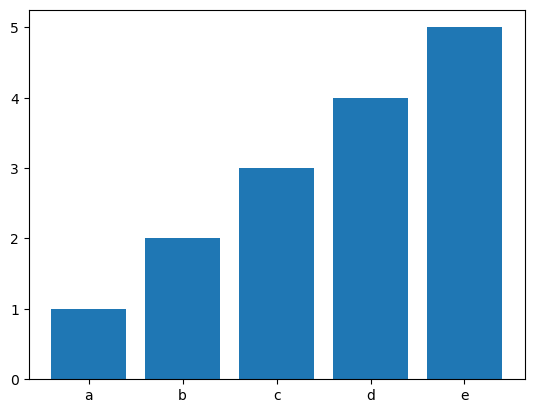

In [4]:
y = [1, 2, 3, 4, 5]
x = ["a","b","c","d","e"]

plt.bar(x, y)

### Gráficos de barras - verticales

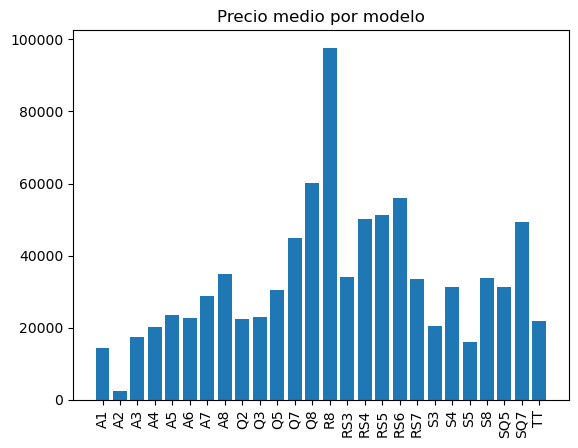

In [22]:
audi = pd.read_csv("../../data/02audi.csv")

resultado = audi.groupby("model").agg({"price":"mean"}).reset_index()

plt.title("Precio medio por modelo")
plt.bar(resultado["model"], resultado["price"])
plt.xticks(rotation=90)
plt.show() # Muestra la gráfica / Cierra el entorno de la gráfica

### Gráficos de barras - Horizontales

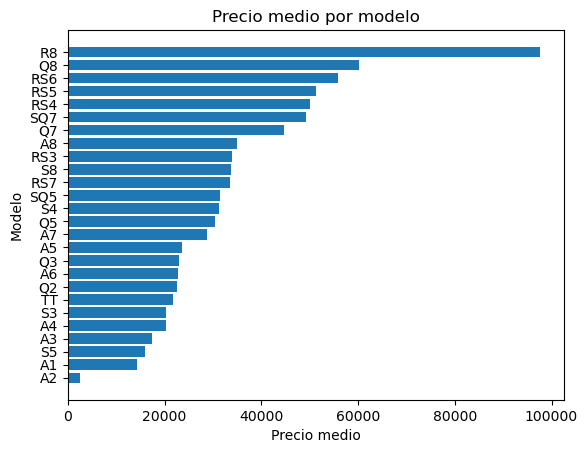

In [29]:
### Gráficos de barras - horizontales
# Cuando tenemos más de 10 categorías es mejor usar barras horizontales
resultado = resultado.sort_values("price")

plt.barh(resultado["model"], resultado["price"])
plt.title("Precio medio por modelo")
plt.xlabel("Precio medio")
plt.ylabel("Modelo")
plt.show()

### Pie Chart

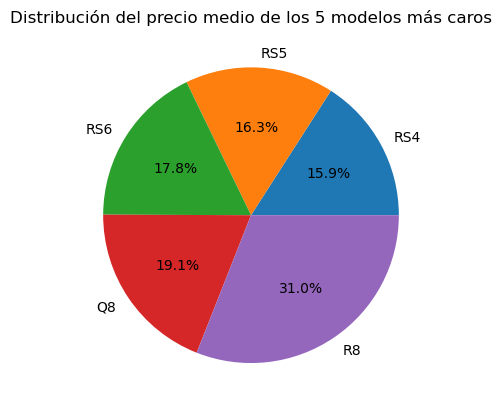

In [44]:
top5 = resultado.tail(5)

plt.pie(top5["price"], labels=top5["model"], autopct="%1.1f%%")
plt.title("Distribución del precio medio de los 5 modelos más caros")
plt.show()

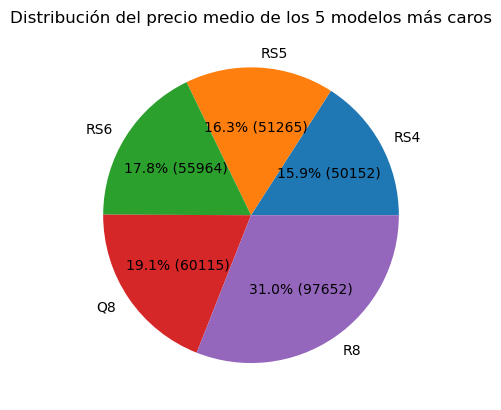

In [43]:
top5 = resultado.tail(5)

def make_autopct(values):
    def my_autopct(pct):
        total = sum(values)
        val = int(round(pct*total/100.0))
        return f"{pct:.1f}% ({val})"
    return my_autopct

plt.pie(top5["price"], labels=top5["model"], autopct=make_autopct(top5["price"]))
plt.title("Distribución del precio medio de los 5 modelos más caros")
plt.show()

### Gráfico de línea - Recomendado para series de tiempo

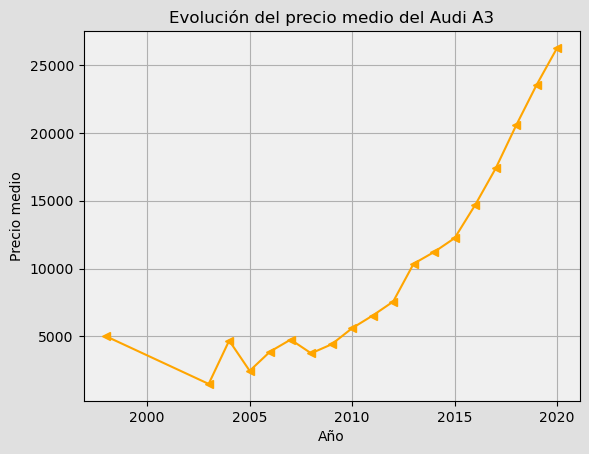

In [52]:
# Para ver cuántos coches hay por modelo
audi.groupby("model").agg({"price":"count"}).reset_index().sort_values("price", ascending=False).head(3)

### Gráfico de línea - Recomendado para series de tiempo
a3_time = audi[audi["model"]=="A3"].groupby("year").agg({"price":"mean"}).reset_index()

plt.plot(a3_time["year"], a3_time["price"], marker='<', color='orange')
plt.title("Evolución del precio medio del Audi A3")
plt.xlabel("Año")
plt.ylabel("Precio medio")
plt.grid()
plt.gca().set_facecolor('#f0f0f0')  # Fondo del área del gráfico
plt.gcf().set_facecolor('#e0e0e0')  # Fondo de todo el lienzo (opcional)
plt.show()

### Scatter plot - Diagrama de dispersión

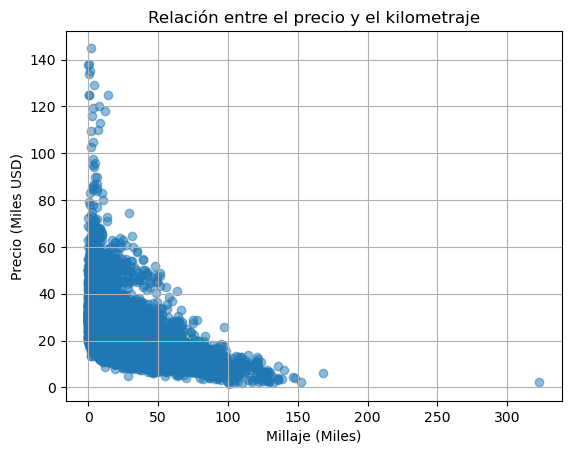

In [60]:
# Scatter plot - Diagrama de dispersión
plt.scatter(audi["mileage"] / 1000, audi["price"] / 1000, alpha=0.5)
plt.title("Relación entre el precio y el kilometraje")
plt.xlabel("Millaje (Miles)")
plt.ylabel("Precio (Miles USD)")
plt.grid()
plt.show()

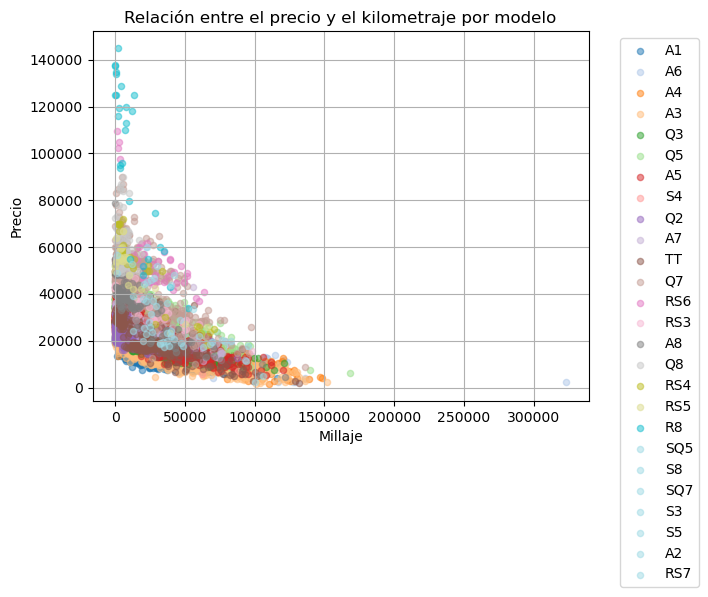

In [55]:
models = audi["model"].unique()
colors = plt.cm.tab20(range(len(models)))  # Paleta de colores

for i, model in enumerate(models):
    subset = audi[audi["model"] == model]
    plt.scatter(subset["mileage"], subset["price"], color=colors[i], label=model, alpha=0.5, s=20)

plt.title("Relación entre el precio y el kilometraje por modelo")
plt.xlabel("Millaje")
plt.ylabel("Precio")
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', ncol=1)
plt.grid()
plt.show()

### Introducción a seaborn

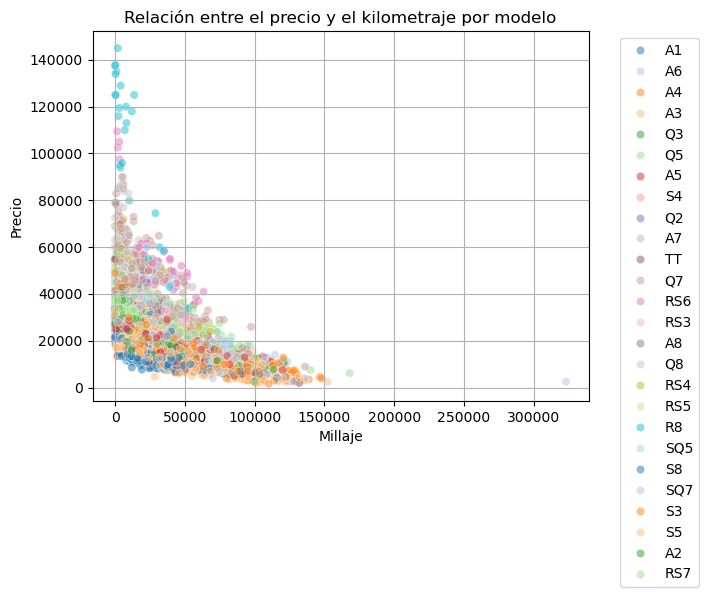

In [61]:
import seaborn as sns

sns.scatterplot(
    data=audi,
    x="mileage",
    y="price",
    hue="model",
    alpha=0.5,
    palette="tab20"
)

plt.title("Relación entre el precio y el kilometraje por modelo")
plt.xlabel("Millaje")
plt.ylabel("Precio")
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', ncol=1)
plt.grid()
plt.show()